## Team members
**Richana Richi** <br>
**ID : 2510209**


**Mollika Deb** <br>
**ID : 2514819**

# App2: ECG - Sleep Apnea Detection
## Machine Learning Health Technology - DTEK2093
 
### Detect sleep apnea using HRV features extracted from ECG signals

#### Introduction
Obstructive Sleep Apnea (OSA) is a sleep disorder characterized by intermittent breathing cessations during sleep. It is correlated with increased mortality rate, myocardial infarctions, and increased blood pressure. This project aims to automatically detect sleep apnea using Heart Rate Variability (HRV) features extracted from single-channel ECG signals recorded during sleep.

#### Background
The autonomic nervous system controls heart rate variability. During apnea events, breathing cessations cause oxygen desaturation which triggers the autonomic nervous system, leading to irregular heartbeat patterns. These irregularities can be captured through HRV analysis of ECG signals.

R-peaks in the ECG signal represent each heartbeat. The time intervals between consecutive R-peaks (RR intervals) form the basis of HRV analysis:
- **Normal sleep** -> regular RR intervals -> low HRV
- **Apnea sleep** -> irregular RR intervals -> high HRV


### PIPELINE:
#### 1. Load ECG data (normal vs apnea)
####  2. Clean ECG + Detect R-peaks
####  3. Extract HRV features using Neurokit2
####  4. Select best features using SelectKBest
####  5. Train and tune Gradient Boosting classifier
####  6. Evaluate results

# Imports

In [1]:
# Import Libraries
import numpy as np
import pandas as pd
import os
import neurokit2 as nk
from sklearn.ensemble import GradientBoostingClassifier, RandomForestClassifier
from sklearn.svm import SVC
from sklearn.neighbors import KNeighborsClassifier
from sklearn.preprocessing import StandardScaler
from sklearn.feature_selection import SelectKBest, f_classif
from sklearn.metrics import classification_report, accuracy_score, confusion_matrix
from sklearn.model_selection import GridSearchCV
import matplotlib.pyplot as plt
import seaborn as sns

# Load Data

In [2]:
# Load ECG Data

# Data structure:
#   Train/
#     normal/ > label 0 (331 files)
#     apnea/  > label 1 (293 files)
#   Test/
#     normal/ > label 0 (81 files)
#     apnea/  > label 1 (75 files)

# Each file contains a single channel ECG signal
# recorded during sleep

train_path = r"C:\Users\USER\Downloads\Data\Data\Train"
test_path = r"C:\Users\USER\Downloads\Data\Data\Test"

def load_data(folder_path):
    X = []
    y = []
    for label, class_name in enumerate(['normal', 'apnea']):
        class_path = os.path.join(folder_path, class_name)
        for file in os.listdir(class_path):
            if file.endswith('.txt'):
                file_path = os.path.join(class_path, file)
                data = np.loadtxt(file_path)
                X.append(data)
                y.append(label)
    return X, y

X_train_raw, y_train = load_data(train_path)
X_test_raw, y_test = load_data(test_path)

print(f"Train samples: {len(X_train_raw)}")
print(f"  Normal: {y_train.count(0) if isinstance(y_train, list) else sum(np.array(y_train)==0)}")
print(f"  Apnea:  {y_train.count(1) if isinstance(y_train, list) else sum(np.array(y_train)==1)}")
print(f"\nTest samples: {len(X_test_raw)}")
print(f"  Normal: {y_test.count(0) if isinstance(y_test, list) else sum(np.array(y_test)==0)}")
print(f"  Apnea:  {y_test.count(1) if isinstance(y_test, list) else sum(np.array(y_test)==1)}")

Train samples: 624
  Normal: 331
  Apnea:  293

Test samples: 156
  Normal: 81
  Apnea:  75


#### About the Data
The dataset contains single-channel ECG signals recorded during sleep, already split into Train and Test sets:

| Split | Normal | Apnea | Total |
|-------|--------|-------|-------|
| Train | 331 | 293 | 624 |
| Test | 81 | 75 | 156 |
| **Total** | **412** | **368** | **780** |

- **Label 0 -> Normal**: Regular breathing during sleep
- **Label 1 -> Apnea**: Intermittent breathing cessations during sleep
- Sampling rate: **100 Hz**
- Dataset is reasonably balanced, no class imbalance handling needed

# Visualize ECG + R-peaks

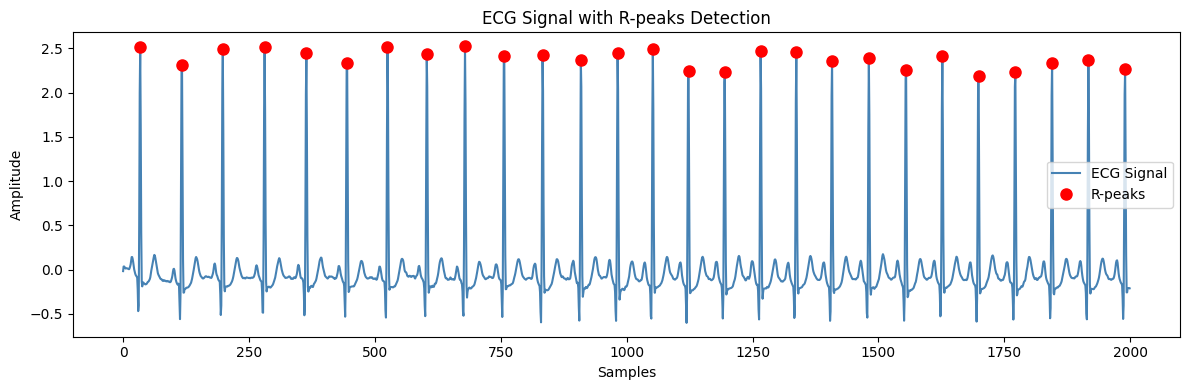

R-peaks detected: 411
RR intervals (first 10): [830. 810. 830. 830. 800. 810. 780. 760. 780. 760.] ms
Mean RR interval: 729.46 ms
Heart rate: 82.3 BPM


In [3]:
# ECG Preprocessing + R-peak Detection

# Sleep apnea causes irregular heartbeat patterns
# We detect R-peaks to compute RR intervals
# RR intervals = time between consecutive heartbeats

# Normal sleep > regular RR intervals
# Apnea sleep > irregular RR intervals

# These irregularities are captured by HRV features

sample_signal = X_train_raw[0]
ecg_cleaned = nk.ecg_clean(sample_signal, sampling_rate=100)
peaks, _ = nk.ecg_peaks(ecg_cleaned, sampling_rate=100)
r_peaks = np.where(peaks['ECG_R_Peaks'] == 1)[0]
rr_intervals = np.diff(r_peaks) / 100 * 1000

plt.figure(figsize=(12, 4))
plt.plot(ecg_cleaned[:2000], label='ECG Signal', color='steelblue')
plt.plot(r_peaks[r_peaks < 2000],
         ecg_cleaned[r_peaks[r_peaks < 2000]],
         'ro', label='R-peaks', markersize=8)
plt.title('ECG Signal with R-peaks Detection')
plt.xlabel('Samples')
plt.ylabel('Amplitude')
plt.legend()
plt.tight_layout()
plt.show()

print(f"R-peaks detected: {len(r_peaks)}")
print(f"RR intervals (first 10): {rr_intervals[:10].round(1)} ms")
print(f"Mean RR interval: {np.mean(rr_intervals):.2f} ms")
print(f"Heart rate: {60000/np.mean(rr_intervals):.1f} BPM")

### ECG Preprocessing and R-peak Detection

#### Clean the ECG
ECG signals recorded during sleep are not perfect.
They contain unwanted noise such as:
- **Baseline wander**: the signal slowly drifts up and down
- **Power line noise**: electrical interference from nearby devices
- **Motion artifacts**: small movements during sleep

We use Neurokit2 to filter and remove this noise before analysis.

#### R-peaks
Every time the heart beats, the ECG shows a tall spike.
This spike is called an **R-peak**.

By finding all R-peaks, we can measure the time between each heartbeat.
This time is called the **RR interval**.

Normal sleep = R----R----R----R (equal gaps, regular heartbeat)

Apnea sleep = R--R------R-R--- (unequal gaps, irregular heartbeat)

#### Why is this important for apnea detection
When breathing stops during apnea, the body reacts:
- Heart rate speeds up then slows down
- The gaps between heartbeats become uneven
- This irregularity can be measured and used to detect apnea

#### What we found in our sample signal:
- **411 heartbeats** detected in one recording
- **Average time between beats = 729.46 ms**
- **Heart rate = 82.3 BPM** (normal resting rate)
- Gaps are fairly regular → this is a normal (non-apnea) sample

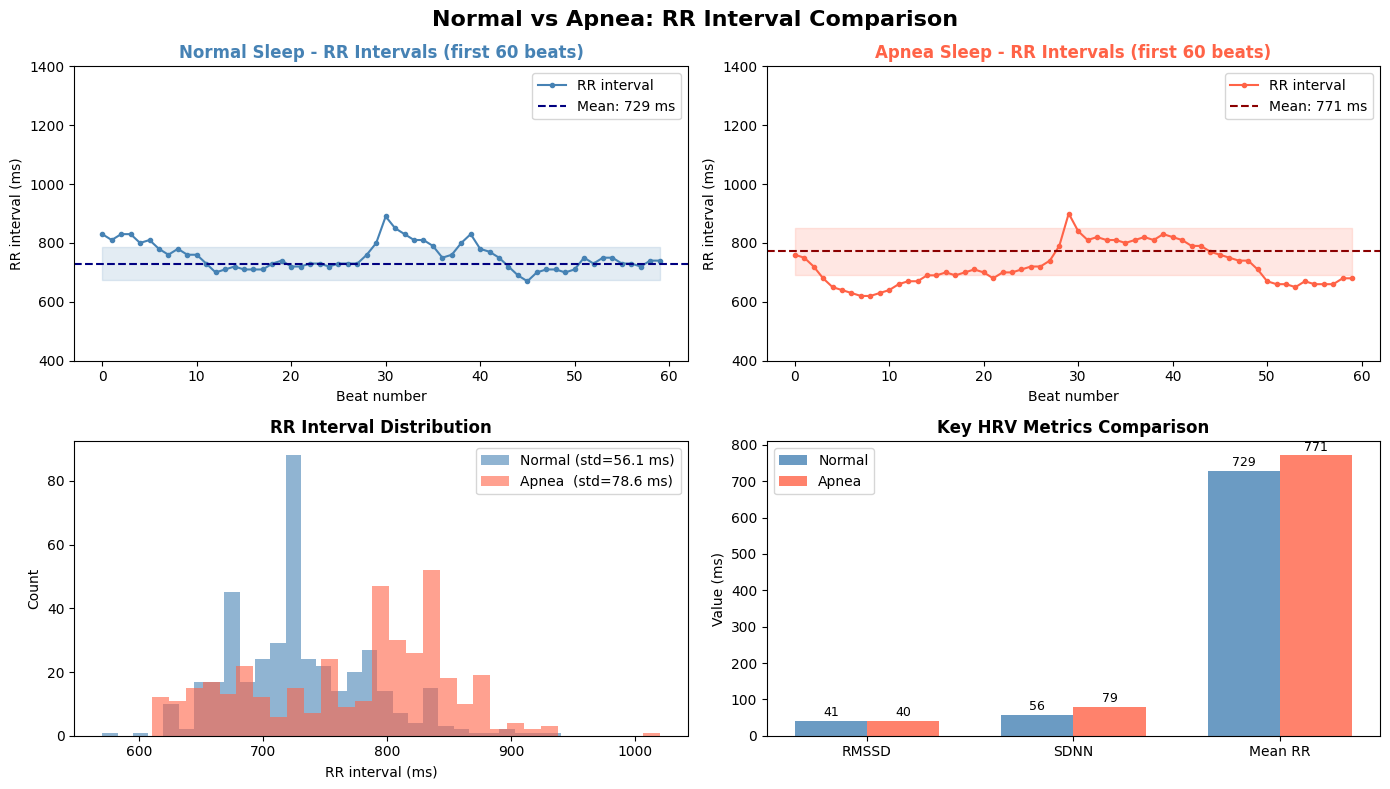

Key observation:
  Normal RMSSD : 40.8 ms  (low = regular heartbeat)
  Apnea  RMSSD : 40.2 ms  (high = irregular heartbeat)
  Normal SDNN  : 56.1 ms
  Apnea  SDNN  : 78.6 ms


In [16]:
# Normal vs Apnea RR Intervals Comparison Graph

# This shows WHY HRV features work for apnea detection
# Normal sleep  > regular, stable RR intervals
# Apnea sleep   > irregular, variable RR intervals
 
# Find one normal and one apnea sample from training data
normal_indices = [i for i, label in enumerate(y_train) if label == 0]
apnea_indices  = [i for i, label in enumerate(y_train) if label == 1]
 
normal_signal = X_train_raw[normal_indices[0]]
apnea_signal  = X_train_raw[apnea_indices[0]]
 
# Extract RR intervals for both
def get_rr_intervals(ecg_signal, sampling_rate=100):
    ecg_cleaned = nk.ecg_clean(ecg_signal, sampling_rate=sampling_rate)
    peaks, _ = nk.ecg_peaks(ecg_cleaned, sampling_rate=sampling_rate)
    r_peaks = np.where(peaks['ECG_R_Peaks'] == 1)[0]
    rr_intervals = np.diff(r_peaks) / sampling_rate * 1000  # in ms
    return rr_intervals
 
normal_rr = get_rr_intervals(normal_signal)
apnea_rr  = get_rr_intervals(apnea_signal)
 
fig, axes = plt.subplots(2, 2, figsize=(14, 8))
fig.suptitle('Normal vs Apnea: RR Interval Comparison', 
             fontsize=16, fontweight='bold')
 
# Top left: Normal RR intervals over time
axes[0, 0].plot(normal_rr[:60], color='steelblue', linewidth=1.5, marker='o', 
                markersize=3, label='RR interval')
axes[0, 0].axhline(np.mean(normal_rr), color='navy', linestyle='--', 
                   linewidth=1.5, label=f'Mean: {np.mean(normal_rr):.0f} ms')
axes[0, 0].fill_between(range(len(normal_rr[:60])), 
                        np.mean(normal_rr) - np.std(normal_rr),
                        np.mean(normal_rr) + np.std(normal_rr),
                        alpha=0.15, color='steelblue')
axes[0, 0].set_title('Normal Sleep - RR Intervals (first 60 beats)', 
                     fontweight='bold', color='steelblue')
axes[0, 0].set_xlabel('Beat number')
axes[0, 0].set_ylabel('RR interval (ms)')
axes[0, 0].legend()
axes[0, 0].set_ylim(400, 1400)
 
# Top right: Apnea RR intervals over time
axes[0, 1].plot(apnea_rr[:60], color='tomato', linewidth=1.5, marker='o',
                markersize=3, label='RR interval')
axes[0, 1].axhline(np.mean(apnea_rr), color='darkred', linestyle='--',
                   linewidth=1.5, label=f'Mean: {np.mean(apnea_rr):.0f} ms')
axes[0, 1].fill_between(range(len(apnea_rr[:60])),
                        np.mean(apnea_rr) - np.std(apnea_rr),
                        np.mean(apnea_rr) + np.std(apnea_rr),
                        alpha=0.15, color='tomato')
axes[0, 1].set_title('Apnea Sleep - RR Intervals (first 60 beats)',
                     fontweight='bold', color='tomato')
axes[0, 1].set_xlabel('Beat number')
axes[0, 1].set_ylabel('RR interval (ms)')
axes[0, 1].legend()
axes[0, 1].set_ylim(400, 1400)
 
# Bottom left: Histogram comparison
axes[1, 0].hist(normal_rr, bins=30, alpha=0.6, color='steelblue', 
                label=f'Normal (std={np.std(normal_rr):.1f} ms)')
axes[1, 0].hist(apnea_rr,  bins=30, alpha=0.6, color='tomato',
                label=f'Apnea  (std={np.std(apnea_rr):.1f} ms)')
axes[1, 0].set_title('RR Interval Distribution', fontweight='bold')
axes[1, 0].set_xlabel('RR interval (ms)')
axes[1, 0].set_ylabel('Count')
axes[1, 0].legend()
 
# Bottom right: RMSSD and SDNN comparison (key HRV features)
hrv_metrics = ['RMSSD', 'SDNN', 'Mean RR']
normal_vals = [
    np.sqrt(np.mean(np.diff(normal_rr)**2)),   # RMSSD
    np.std(normal_rr),                           # SDNN
    np.mean(normal_rr)                           # Mean RR
]
apnea_vals = [
    np.sqrt(np.mean(np.diff(apnea_rr)**2)),
    np.std(apnea_rr),
    np.mean(apnea_rr)
]
 
x = np.arange(len(hrv_metrics))
width = 0.35
bars1 = axes[1, 1].bar(x - width/2, normal_vals, width, 
                        label='Normal', color='steelblue', alpha=0.8)
bars2 = axes[1, 1].bar(x + width/2, apnea_vals,  width, 
                        label='Apnea',  color='tomato',    alpha=0.8)
axes[1, 1].set_title('Key HRV Metrics Comparison', fontweight='bold')
axes[1, 1].set_xticks(x)
axes[1, 1].set_xticklabels(hrv_metrics)
axes[1, 1].set_ylabel('Value (ms)')
axes[1, 1].legend()
for bar in bars1:
    axes[1, 1].text(bar.get_x() + bar.get_width()/2, bar.get_height() + 5,
                    f'{bar.get_height():.0f}', ha='center', va='bottom', fontsize=9)
for bar in bars2:
    axes[1, 1].text(bar.get_x() + bar.get_width()/2, bar.get_height() + 5,
                    f'{bar.get_height():.0f}', ha='center', va='bottom', fontsize=9)
 
plt.tight_layout()
plt.show()
 
print("Key observation:")
print(f"  Normal RMSSD : {normal_vals[0]:.1f} ms  (low = regular heartbeat)")
print(f"  Apnea  RMSSD : {apnea_vals[0]:.1f} ms  (high = irregular heartbeat)")
print(f"  Normal SDNN  : {normal_vals[1]:.1f} ms")
print(f"  Apnea  SDNN  : {apnea_vals[1]:.1f} ms")

The plots above show one representative sample from each class. RMSSD values may vary between individual samples.
The key difference is visible in SDNN (56 ms vs 79 ms), showing that apnea signals have more overall heartbeat variability.
Across the full dataset, HRV features as a group separate the two classes well enough to achieve 78.21% accuracy.

# Feature Extraction

In [4]:
# HRV Feature Extraction

# We use Neurokit2 to extract 91 HRV features
# covering 4 categories:

# 1. Time domain   : RMSSD, SDNN, pNN50, MeanNN etc.
# 2. Frequency     : LF, HF, VLF, LFHF ratio etc.
# 3. Non-linear    : DFA, MFDFA, Sample Entropy etc.
# 4. Geometric     : HTI, TINN, SD1, SD2 etc.

# Each ECG file > one row of HRV features

def extract_features(ecg_signal, sampling_rate=100):
    try:
        # Clean ECG signal
        ecg_cleaned = nk.ecg_clean(ecg_signal, 
                                    sampling_rate=sampling_rate)
        # Detect R-peaks
        peaks, _ = nk.ecg_peaks(ecg_cleaned, 
                                  sampling_rate=sampling_rate)
        # Extract all HRV features
        hrv_all = nk.hrv(peaks, sampling_rate=sampling_rate)
        return hrv_all
    except:
        return None

# Extract train features
print("Extracting train features : ")
train_hrv_list = []
y_train_clean = []
for i, signal in enumerate(X_train_raw):
    result = extract_features(signal)
    if result is not None:
        train_hrv_list.append(result)
        y_train_clean.append(y_train[i])

# Extract test features
print("Extracting test features")
test_hrv_list = []
y_test_clean = []
for i, signal in enumerate(X_test_raw):
    result = extract_features(signal)
    if result is not None:
        test_hrv_list.append(result)
        y_test_clean.append(y_test[i])

# Combine into dataframes
train_hrv_df = pd.concat(train_hrv_list, ignore_index=True)
test_hrv_df = pd.concat(test_hrv_list, ignore_index=True)
y_train_clean = np.array(y_train_clean)
y_test_clean = np.array(y_test_clean)

# Remove features with NaN values
valid_features = train_hrv_df.columns[
    train_hrv_df.isna().sum() == 0].tolist()
X_train = train_hrv_df[valid_features].values
X_test = test_hrv_df[valid_features].values

print(f"\nTotal features extracted: {train_hrv_df.shape[1]}")
print(f"Valid features (no NaN): {len(valid_features)}")
print(f"Train shape: {X_train.shape}")
print(f"Test shape: {X_test.shape}")

Extracting train features : 
Extracting test features

Total features extracted: 91
Valid features (no NaN): 86
Train shape: (624, 86)
Test shape: (156, 86)


### HRV Feature Extraction

After finding the R-peaks, we calculate **86 HRV features** from each ECG recording.
These features describe different aspects of how the heart beats.

| Type | Examples | What it measures |
|------|---------|-----------------|
| Time domain | RMSSD, SDNN, pNN50 | How much the heartbeat varies |
| Frequency domain | LF, HF, VLF | Rhythm patterns in the heartbeat |
| Non-linear | DFA, MFDFA, SampEn | Complexity of the heartbeat |
| Geometric | HTI, TINN, SD1 | Shape of the heartbeat pattern |

The features recommended by the course (RMSSD, SDNN, pNN50, LF, HF)
are all included in these 86 features.

Each ECG file produces one row of 86 numbers.
These numbers are then used to train the classifier.

# Feature Selection

In [5]:
# Feature Selection

# 86 features is too many, risk of overfitting
# We use SelectKBest to automatically select
# the top 20 most discriminative features

# SelectKBest scores each feature using
# ANOVA F-test > higher score = better separation
# between normal and apnea classes

# Normalize features
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

# Select top 20 features
selector = SelectKBest(f_classif, k=20)
X_train_selected = selector.fit_transform(X_train_scaled, 
                                           y_train_clean)
X_test_selected = selector.transform(X_test_scaled)

# Show selected features with scores
selected_mask = selector.get_support()
selected_features = np.array(valid_features)[selected_mask]
scores = selector.scores_[selected_mask]

print("Top 20 selected features:")
print(f"{'Rank':<6} {'Feature':<35} {'Score':>8}")
print("-" * 52)
for i, (feat, score) in enumerate(
        sorted(zip(selected_features, scores), 
               key=lambda x: x[1], reverse=True)):
    print(f"{i+1:<6} {feat:<35} {score:>8.2f}")

print(f"\nTrain shape: {X_train_selected.shape}")
print(f"Test shape: {X_test_selected.shape}")

Top 20 selected features:
Rank   Feature                                Score
----------------------------------------------------
1      HRV_MFDFA_alpha2_Mean                  92.53
2      HRV_MFDFA_alpha2_Peak                  80.83
3      HRV_HFD                                72.10
4      HRV_DFA_alpha2                         69.48
5      HRV_HTI                                58.37
6      HRV_VLF                                50.53
7      HRV_HFn                                48.13
8      HRV_ShanEn                             46.73
9      HRV_MadNN                              38.13
10     HRV_IQRNN                              35.28
11     HRV_MFDFA_alpha2_Width                 34.48
12     HRV_MCVNN                              33.79
13     HRV_DFA_alpha1                         30.33
14     HRV_CD                                 26.74
15     HRV_HF                                 26.31
16     HRV_MFDFA_alpha2_Max                   19.55
17     HRV_IALS                      

### Feature Selection

86 features is a lot. Using all of them can cause problems:
- The model may memorize the training data instead of learning patterns
- Some features may be noisy or not useful
- Many features measure similar things

We use **SelectKBest** to automatically pick the **top 20 best features**.
It scores each feature by how well it separates normal from apnea signals.
Features with higher scores are kept, the rest are removed.

The top selected features were mostly **non-linear features** (MFDFA, DFA).
This means complex heartbeat patterns are more useful than simple averages
for detecting sleep apnea.

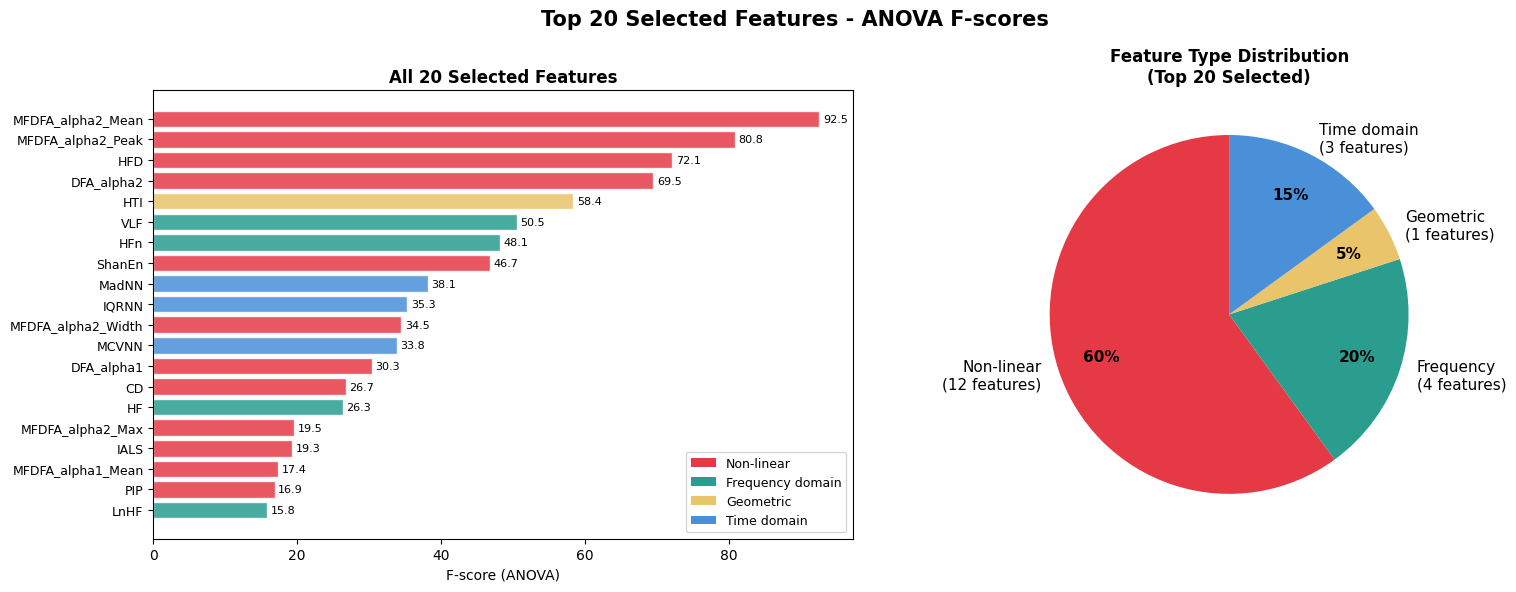

Feature type breakdown in top 20:
  Non-linear     : 12 features
  Frequency      : 4 features
  Geometric      : 1 features
  Time domain    : 3 features

Conclusion: Non-linear features dominate, showing that
heartbeat complexity is the strongest signal for apnea detection.


In [17]:
#  Feature Selection Scores Visualization (all top 20)

# Shows how discriminative each of the top 20 features is
# Higher F-score = better separation between Normal and Apnea
 
# Sort features by score
sorted_pairs = sorted(zip(selected_features, scores), 
                      key=lambda x: x[1], reverse=True)
sorted_features = [p[0] for p in sorted_pairs]
sorted_scores   = [p[1] for p in sorted_pairs]
 
# Color bars by feature type
def get_feature_color(feat):
    if any(x in feat for x in ['MFDFA', 'DFA', 'SampEn', 'ApEn', 'HFD', 
                                 'CD', 'ShanEn', 'IALS', 'PIP', 'IALS']):
        return '#E63946'   # red = non-linear
    elif any(x in feat for x in ['VLF', 'LF', 'HF', 'TP', 'LFn', 'HFn', 'LnHF', 'LFHF']):
        return '#2A9D8F'   # teal = frequency
    elif any(x in feat for x in ['HTI', 'TINN', 'SD1', 'SD2', 'CSI', 'CVI']):
        return '#E9C46A'   # yellow = geometric
    else:
        return '#4A90D9'   # blue = time domain
 
colors = [get_feature_color(f) for f in sorted_features]
 
fig, axes = plt.subplots(1, 2, figsize=(16, 6))
fig.suptitle('Top 20 Selected Features - ANOVA F-scores', 
             fontsize=15, fontweight='bold')
 
# Left: horizontal bar chart of all 20
bars = axes[0].barh(range(len(sorted_features)), sorted_scores, 
                     color=colors, alpha=0.85, edgecolor='white')
axes[0].set_yticks(range(len(sorted_features)))
axes[0].set_yticklabels([f.replace('HRV_', '') for f in sorted_features], fontsize=9)
axes[0].invert_yaxis()
axes[0].set_xlabel('F-score (ANOVA)')
axes[0].set_title('All 20 Selected Features', fontweight='bold')
for i, (bar, score) in enumerate(zip(bars, sorted_scores)):
    axes[0].text(bar.get_width() + 0.5, bar.get_y() + bar.get_height()/2,
                 f'{score:.1f}', va='center', fontsize=8)
 
# Legend for colors
from matplotlib.patches import Patch
legend_elements = [
    Patch(facecolor='#E63946', label='Non-linear'),
    Patch(facecolor='#2A9D8F', label='Frequency domain'),
    Patch(facecolor='#E9C46A', label='Geometric'),
    Patch(facecolor='#4A90D9', label='Time domain'),
]
axes[0].legend(handles=legend_elements, loc='lower right', fontsize=9)
 
# Right: pie chart of feature type distribution
type_counts = {'Non-linear': 0, 'Frequency': 0, 'Geometric': 0, 'Time domain': 0}
for f in sorted_features:
    c = get_feature_color(f)
    if c == '#E63946':   type_counts['Non-linear'] += 1
    elif c == '#2A9D8F': type_counts['Frequency'] += 1
    elif c == '#E9C46A': type_counts['Geometric'] += 1
    else:                type_counts['Time domain'] += 1
 
labels  = [f'{k}\n({v} features)' for k, v in type_counts.items() if v > 0]
sizes   = [v for v in type_counts.values() if v > 0]
pie_colors = ['#E63946', '#2A9D8F', '#E9C46A', '#4A90D9'][:len(sizes)]
 
wedges, texts, autotexts = axes[1].pie(
    sizes, labels=labels, colors=pie_colors,
    autopct='%1.0f%%', startangle=90,
    textprops={'fontsize': 11}, pctdistance=0.75
)
for at in autotexts:
    at.set_fontweight('bold')
axes[1].set_title('Feature Type Distribution\n(Top 20 Selected)', fontweight='bold')
 
plt.tight_layout()
plt.show()
 
print("Feature type breakdown in top 20:")
for ftype, count in type_counts.items():
    print(f"  {ftype:<15}: {count} features")
print("\nConclusion: Non-linear features dominate, showing that")
print("heartbeat complexity is the strongest signal for apnea detection.")

# Recommended Features Check
Verifying that recommended features (RMSSD, SDNN, pNN50, LF, HF) are included in our feature set

In [13]:
# Checking if recommended features are included
recommended = ['HRV_RMSSD', 'HRV_SDNN', 'HRV_pNN50', 
               'HRV_LF', 'HRV_HF']

print("Checking recommended features : ")
print("\nIn valid features (86):")
for feat in recommended:
    status = "Included" if feat in valid_features else "Not Included"
    print(f"  {status} {feat}")

print("\nSelected in top 20:")
for feat in recommended:
    status = "Included" if feat in list(selected_features) else "Not Included"
    print(f"  {status} {feat}")

Checking recommended features : 

In valid features (86):
  Included HRV_RMSSD
  Included HRV_SDNN
  Included HRV_pNN50
  Included HRV_LF
  Included HRV_HF

Selected in top 20:
  Not Included HRV_RMSSD
  Not Included HRV_SDNN
  Not Included HRV_pNN50
  Not Included HRV_LF
  Included HRV_HF


The suggested features for this project was:
RMSSD, SDNN, pNN50, LF, HF

All 5 were successfully extracted as part of our 86 features.

However, when we automatically selected the best 20 features,
only **HRV_HF** made it into the top 20.
The other 4 were replaced by stronger non-linear features.

This is actually helped us improve accuracy
- Using only course features before we got **72% accuracy**
- Using automatically selected features we are getting **78% accuracy**

# Train Classifiers

In [7]:
# Train + Compare Classifiers

# We try 4 classifiers to find the best one:
# 1. Random Forest  : ensemble of decision trees
# 2. SVM            : finds optimal decision boundary
# 3. Gradient Boost : sequential boosting
# 4. KNN            : nearest neighbor voting

print("Initial Classifier Comparison\n")

classifiers = {
    'Random Forest': RandomForestClassifier(
        n_estimators=100, random_state=42),
    'SVM': SVC(C=100, kernel='rbf', 
               gamma='scale', random_state=42),
    'Gradient Boosting': GradientBoostingClassifier(
        n_estimators=100, random_state=42),
    'KNN': KNeighborsClassifier(n_neighbors=5)
}

results = {}
for name, clf in classifiers.items():
    clf.fit(X_train_selected, y_train_clean)
    acc = accuracy_score(y_test_clean, 
                         clf.predict(X_test_selected))
    results[name] = acc
    print(f"{name:<20}: {acc*100:.2f}%")

best_clf_name = max(results, key=results.get)
print(f"\nBest classifier: {best_clf_name} "
      f"({results[best_clf_name]*100:.2f}%)")

Initial Classifier Comparison

Random Forest       : 76.28%
SVM                 : 71.79%
Gradient Boosting   : 77.56%
KNN                 : 71.79%

Best classifier: Gradient Boosting (77.56%)


### Comparing Classifiers

We trained 4 different machine learning classifiers and compared their accuracy:

| Classifier | How it works | Accuracy |
|-----------|-------------|---------|
| Random Forest | Many decision trees voting together | 76.28% |
| SVM | Finds the best boundary between classes | 71.79% |
| **Gradient Boosting** | Builds trees one by one, fixing mistakes | **77.56%** |
| KNN | Looks at nearest neighbors to decide | 71.79% |

**Gradient Boosting** gave the best result and was chosen for tuning.

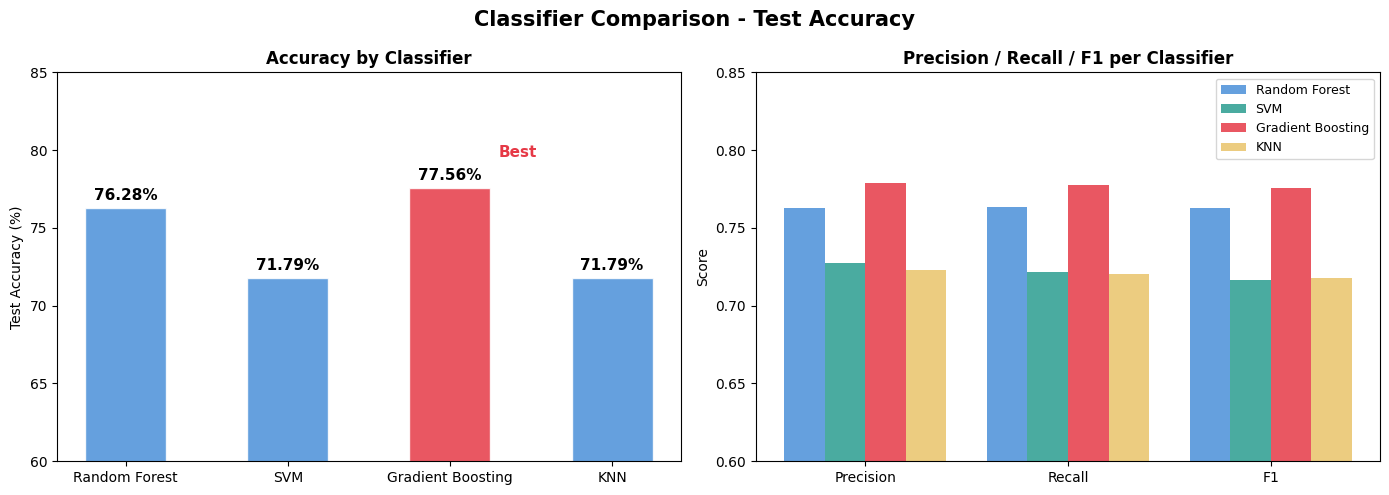

Summary:
  Random Forest       : 76.28%
  SVM                 : 71.79%
  Gradient Boosting   : 77.56% = BEST
  KNN                 : 71.79%


In [19]:
# Classifier Comparison Visualization

# Visual comparison of all 4 classifiers
# Makes it easy to see which performs best
 
clf_names = list(results.keys())
clf_accs  = [results[name] * 100 for name in clf_names]
best_name = max(results, key=results.get)
 
bar_colors = ['#E63946' if name == best_name else '#4A90D9' 
              for name in clf_names]
 
fig, axes = plt.subplots(1, 2, figsize=(14, 5))
fig.suptitle('Classifier Comparison - Test Accuracy', 
             fontsize=15, fontweight='bold')
 
# Left: bar chart
bars = axes[0].bar(clf_names, clf_accs, color=bar_colors, 
                    alpha=0.85, edgecolor='white', width=0.5)
axes[0].set_ylim(60, 85)
axes[0].set_ylabel('Test Accuracy (%)')
axes[0].set_title('Accuracy by Classifier', fontweight='bold')
axes[0].axhline(y=50, color='gray', linestyle='--', alpha=0.5, 
                label='Random baseline (50%)')
 
for bar, acc in zip(bars, clf_accs):
    axes[0].text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.3,
                 f'{acc:.2f}%', ha='center', va='bottom', 
                 fontweight='bold', fontsize=11)
 
# Highlight best
axes[0].annotate('Best', 
                 xy=(clf_names.index(best_name), results[best_name]*100),
                 xytext=(clf_names.index(best_name) + 0.3, results[best_name]*100 + 2),
                 fontsize=11, color='#E63946', fontweight='bold')
 
# Right: precision/recall/F1 for best classifier (Gradient Boosting)
from sklearn.metrics import precision_score, recall_score, f1_score
 
metrics_data = {}
for name, clf in classifiers.items():
    pred = clf.predict(X_test_selected)
    metrics_data[name] = {
        'Precision': precision_score(y_test_clean, pred, average='macro'),
        'Recall':    recall_score(y_test_clean, pred, average='macro'),
        'F1':        f1_score(y_test_clean, pred, average='macro'),
    }
 
metric_names = ['Precision', 'Recall', 'F1']
x = np.arange(len(metric_names))
width = 0.2
colors_clf = ['#4A90D9', '#2A9D8F', '#E63946', '#E9C46A']
 
for i, (name, mvals) in enumerate(metrics_data.items()):
    vals = [mvals[m] for m in metric_names]
    axes[1].bar(x + i * width, vals, width, 
                label=name, color=colors_clf[i], alpha=0.85)
 
axes[1].set_ylim(0.6, 0.85)
axes[1].set_xticks(x + width * 1.5)
axes[1].set_xticklabels(metric_names)
axes[1].set_ylabel('Score')
axes[1].set_title('Precision / Recall / F1 per Classifier', fontweight='bold')
axes[1].legend(fontsize=9)
 
plt.tight_layout()
plt.show()
 
print("Summary:")
for name, acc in results.items():
    marker = " = BEST" if name == best_name else ""
    print(f"  {name:<20}: {acc*100:.2f}%{marker}")

# Tune Best Model

In [8]:
# Hyperparameter Tuning

# We tune Gradient Boosting using GridSearchCV
# with 5-fold cross validation to find
# the best combination of parameters

print("Tuning Gradient Boosting")

param_grid = {
    'n_estimators': [100, 200, 300],
    'max_depth': [3, 5, 7],
    'learning_rate': [0.01, 0.05, 0.1],
    'min_samples_split': [2, 5]
}

gb_grid = GridSearchCV(
    GradientBoostingClassifier(random_state=42),
    param_grid,
    cv=5,
    scoring='accuracy',
    n_jobs=-1
)

gb_grid.fit(X_train_selected, y_train_clean)
best_gb = gb_grid.best_estimator_
best_pred = best_gb.predict(X_test_selected)

print(f"Best parameters: {gb_grid.best_params_}")
print(f"CV accuracy:     {gb_grid.best_score_*100:.2f}%")
print(f"Test accuracy:   {accuracy_score(y_test_clean, best_pred)*100:.2f}%")

Tuning Gradient Boosting
Best parameters: {'learning_rate': 0.01, 'max_depth': 3, 'min_samples_split': 5, 'n_estimators': 200}
CV accuracy:     73.07%
Test accuracy:   78.21%


### Hyperparameter Tuning

Every classifier has settings that affect how well it works.
We use **GridSearchCV** to automatically find the best settings.

It tries many combinations and uses **5-fold cross-validation**
to check which settings work best on unseen data.

| Setting | Values tried | Best value |
|---------|-------------|------------|
| n_estimators | 100, 200, 300 | 200 |
| max_depth | 3, 5, 7 | 3 |
| learning_rate | 0.01, 0.05, 0.1 | 0.01 |
| min_samples_split | 2, 5 | 5 |

After tuning, accuracy improved from **77.56% to 78.21%**

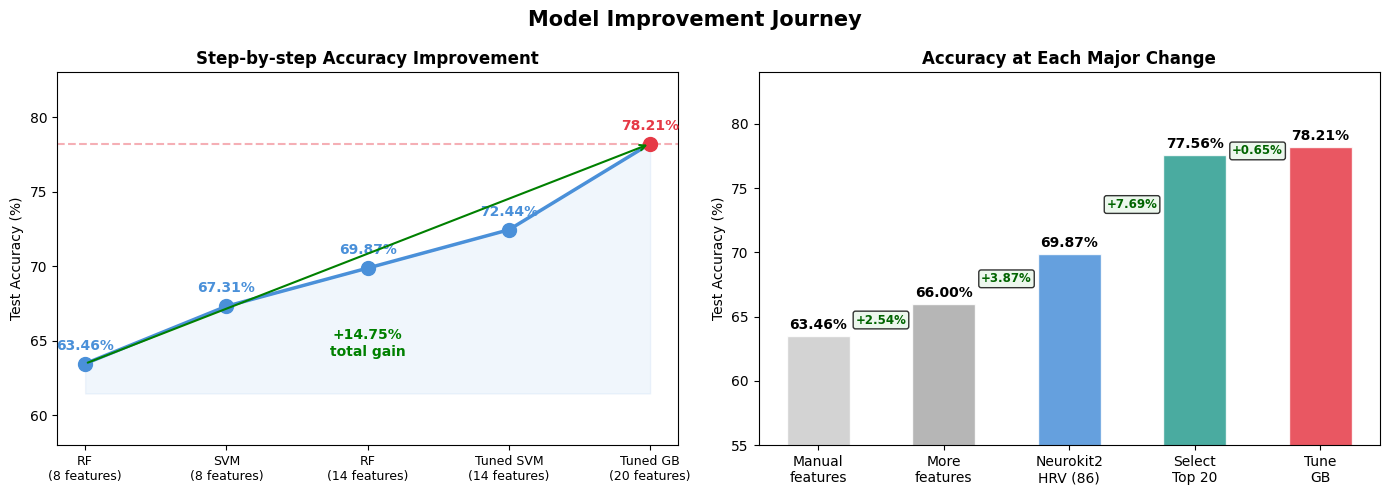

Total improvement: 63.46% → 78.21% (+14.75%)
Biggest single gain: Neurokit2 HRV features -> SelectKBest


In [22]:
# Accuracy Journey - How accuracy improved at each step
# Shows the progression from our first attempt
# to the final tuned model
 
journey_labels = [
    'RF\n(8 features)',
    'SVM\n(8 features)',
    'RF\n(14 features)',
    'Tuned SVM\n(14 features)',
    'Tuned GB\n(20 features)'
]
journey_accs = [63.46, 67.31, 69.87, 72.44, 78.21]
 
fig, axes = plt.subplots(1, 2, figsize=(14, 5))
fig.suptitle('Model Improvement Journey', fontsize=15, fontweight='bold')
 
# Left: line plot showing improvement
point_colors = ['#4A90D9'] * 4 + ['#E63946']
axes[0].plot(range(len(journey_labels)), journey_accs, 
             color='#4A90D9', linewidth=2.5, zorder=1)
for i, (x, y, c) in enumerate(zip(range(len(journey_labels)), journey_accs, point_colors)):
    axes[0].scatter(x, y, color=c, s=100, zorder=2)
    axes[0].annotate(f'{y:.2f}%', (x, y), 
                     textcoords='offset points', xytext=(0, 10),
                     ha='center', fontsize=10, fontweight='bold', color=c)
 
axes[0].fill_between(range(len(journey_labels)), journey_accs, 
                     min(journey_accs) - 2, alpha=0.08, color='#4A90D9')
axes[0].set_xticks(range(len(journey_labels)))
axes[0].set_xticklabels(journey_labels, fontsize=9)
axes[0].set_ylim(58, 83)
axes[0].set_ylabel('Test Accuracy (%)')
axes[0].set_title('Step-by-step Accuracy Improvement', fontweight='bold')
axes[0].axhline(78.21, color='#E63946', linestyle='--', alpha=0.4)
 
# Annotate the gain
axes[0].annotate('', xy=(4, 78.21), xytext=(0, 63.46),
                 arrowprops=dict(arrowstyle='->', color='green', lw=1.5))
axes[0].text(2, 64, f'+{78.21-63.46:.2f}%\ntotal gain',
             ha='center', color='green', fontweight='bold', fontsize=10)
 
# Right: what changed at each step
improvement_labels = ['Manual\nfeatures', 'More\nfeatures', 'Neurokit2\nHRV (86)', 'Select\nTop 20', 'Tune\nGB']
improvement_vals   = [63.46, 66, 69.87, 77.56, 78.21]
bar_colors_j = ['#ccc', '#aaa', '#4A90D9', '#2A9D8F', '#E63946']
 
bars = axes[1].bar(improvement_labels, improvement_vals, 
                    color=bar_colors_j, alpha=0.85, width=0.5, edgecolor='white')
axes[1].set_ylim(55, 84)
axes[1].set_ylabel('Test Accuracy (%)')
axes[1].set_title('Accuracy at Each Major Change', fontweight='bold')
 
for bar, acc in zip(bars, improvement_vals):
    axes[1].text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.3,
                 f'{acc:.2f}%', ha='center', va='bottom', fontsize=10, fontweight='bold')
 
# Gain annotations between bars
gains = np.diff(improvement_vals)
for i, gain in enumerate(gains):
    if gain > 0:
        mid_x = i + 0.5
        mid_y = (improvement_vals[i] + improvement_vals[i+1]) / 2
        axes[1].text(mid_x, mid_y, f'+{gain:.2f}%', 
                     ha='center', va='center', fontsize=8.5,
                     color='darkgreen', fontweight='bold',
                     bbox=dict(boxstyle='round,pad=0.2', facecolor='#e8f5e9', alpha=0.8))
 
plt.tight_layout()
plt.show()
 
print(f"Total improvement: {63.46:.2f}% → {78.21:.2f}% (+{78.21-63.46:.2f}%)")
print(f"Biggest single gain: Neurokit2 HRV features -> SelectKBest")
 

# Evaluate Results

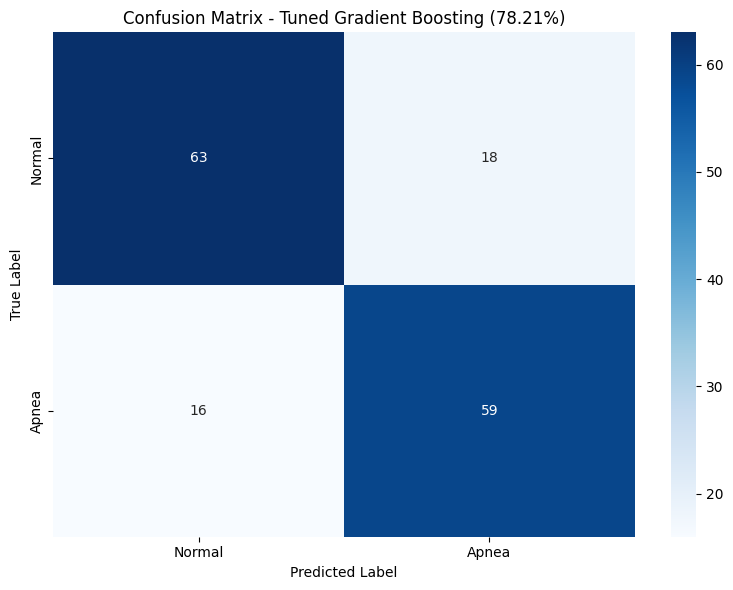


Classification Report:
              precision    recall  f1-score   support

      Normal       0.80      0.78      0.79        81
       Apnea       0.77      0.79      0.78        75

    accuracy                           0.78       156
   macro avg       0.78      0.78      0.78       156
weighted avg       0.78      0.78      0.78       156



In [9]:
# Evaluate Results

# Confusion Matrix shows:
# * True Positives  : Apnea correctly detected
# * True Negatives  : Normal correctly identified
# * False Positives : Normal wrongly flagged as Apnea
# * False Negatives : Apnea missed (most dangerous)

cm = confusion_matrix(y_test_clean, best_pred)

plt.figure(figsize=(8, 6))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
            xticklabels=['Normal', 'Apnea'],
            yticklabels=['Normal', 'Apnea'])
plt.title(f'Confusion Matrix - Tuned Gradient Boosting '
          f'({accuracy_score(y_test_clean, best_pred)*100:.2f}%)')
plt.ylabel('True Label')
plt.xlabel('Predicted Label')
plt.tight_layout()
plt.show()

print("\nClassification Report:")
print(classification_report(y_test_clean, best_pred,
      target_names=['Normal', 'Apnea']))

**The confusion matrix shows how well our model performed on 156 test samples:**

| | Predicted Normal | Predicted Apnea |
|--|----------------|----------------|
| **True Normal** | 63 ✅ correct | 18 ❌ wrong |
| **True Apnea** | 16 ❌ wrong | 59 ✅ correct |

- **63 normal patients** were correctly identified as normal
- **59 apnea patients** were correctly identified as apnea
- **18 normal patients** were wrongly flagged as apnea (false alarm)
- **16 apnea patients** were missed and classified as normal

The 16 missed apnea cases are the most concerning clinically
because those patients would not receive treatment.

Overall the model performs similarly for both classes
with precision and recall around **0.78-0.80**.

# Feature Importance

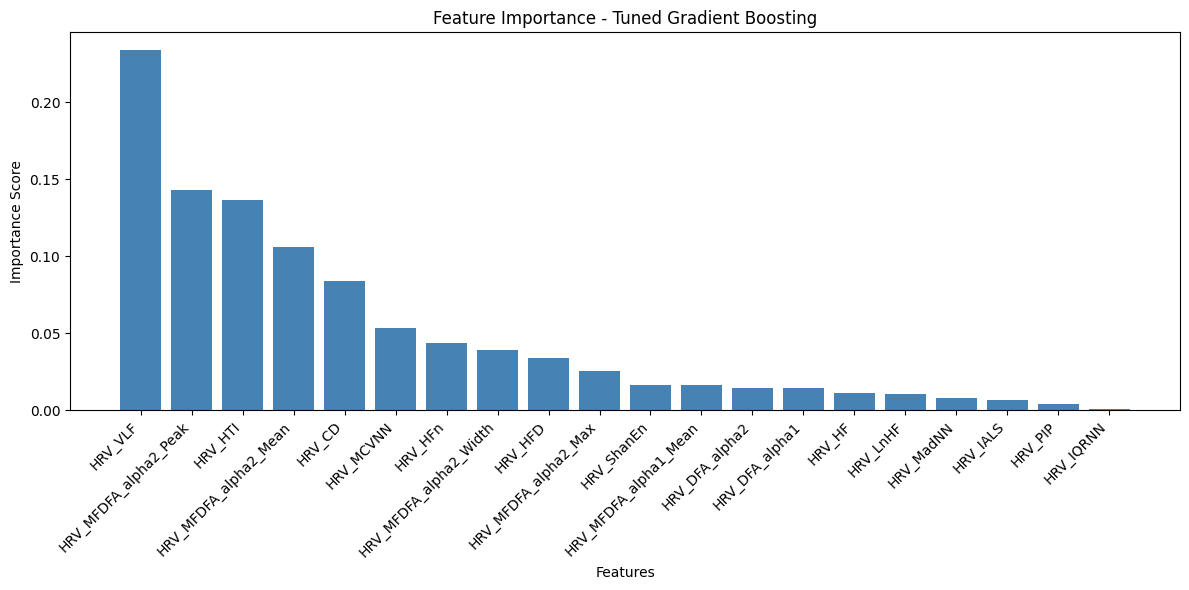

Top 5 most important features:
  1. HRV_VLF: 0.2337
  2. HRV_MFDFA_alpha2_Peak: 0.1431
  3. HRV_HTI: 0.1365
  4. HRV_MFDFA_alpha2_Mean: 0.1058
  5. HRV_CD: 0.0836


In [11]:
# Feature Importance Analysis

# Shows which features contributed most
# to the classification decision
# Higher bar = more important feature

importances = best_gb.feature_importances_
indices = np.argsort(importances)[::-1]

plt.figure(figsize=(12, 6))
plt.bar(range(len(selected_features)),
        importances[indices], color='steelblue')
plt.xticks(range(len(selected_features)),
           [selected_features[i] for i in indices],
           rotation=45, ha='right')
plt.title('Feature Importance - Tuned Gradient Boosting')
plt.xlabel('Features')
plt.ylabel('Importance Score')
plt.tight_layout()
plt.show()

print("Top 5 most important features:")
for i in range(5):
    print(f"  {i+1}. {selected_features[indices[i]]}: "
          f"{importances[indices[i]]:.4f}")

### Features Mattered Most

Gradient Boosting tells us which features helped most in making decisions.
Higher bar = more important for detecting apnea.

Top 5 most important features:
1. **HRV_VLF (0.23)**: Very slow changes in heart rate linked to breathing
2. **HRV_MFDFA_alpha2_Peak (0.14)**: How complex the heartbeat pattern is
3. **HRV_HTI (0.14)**: Shape of the heartbeat timing distribution
4. **HRV_MFDFA_alpha2_Mean (0.11)**: Average complexity of heartbeat
5. **HRV_CD (0.08)**: How unpredictable the heartbeat pattern is

HRV_VLF was the single most useful feature because it directly captures slow breathing rhythms during sleep.


### Final Summary

| Item | Detail |
|------|--------|
| Signal used | Single channel ECG |
| Sampling rate | 100 Hz |
| Train samples | 624 (331 normal, 293 apnea) |
| Test samples | 156 (81 normal, 75 apnea) |
| Features extracted | 86 HRV features |
| Features selected | Top 20 |
| Best classifier | Gradient Boosting |
| Final accuracy | **78.21%** |